## Compress Sensing and POD-QDEIM

In [97]:
# importing necessary libraries, data files and functions
import numpy as np
import matplotlib.pyplot as plt

# Loading data from the dat file obtained from PCE
Cd_data = np.loadtxt('pce_uq_results.dat', skiprows=1, usecols=range(5, 1204))
Cl_data = np.loadtxt('pce_uq_results.dat', skiprows=1, usecols=range(1205, 2404))
# The first four columns are eval_id, interface, x1, x2 
param_viscosity = np.loadtxt('pce_uq_results.dat', skiprows=1, usecols=2)
param_density = np.loadtxt('pce_uq_results.dat', skiprows=1, usecols=3)
# # making the data from each analysis a column vector
Cd_data = Cd_data.T
Cl_data = Cl_data.T

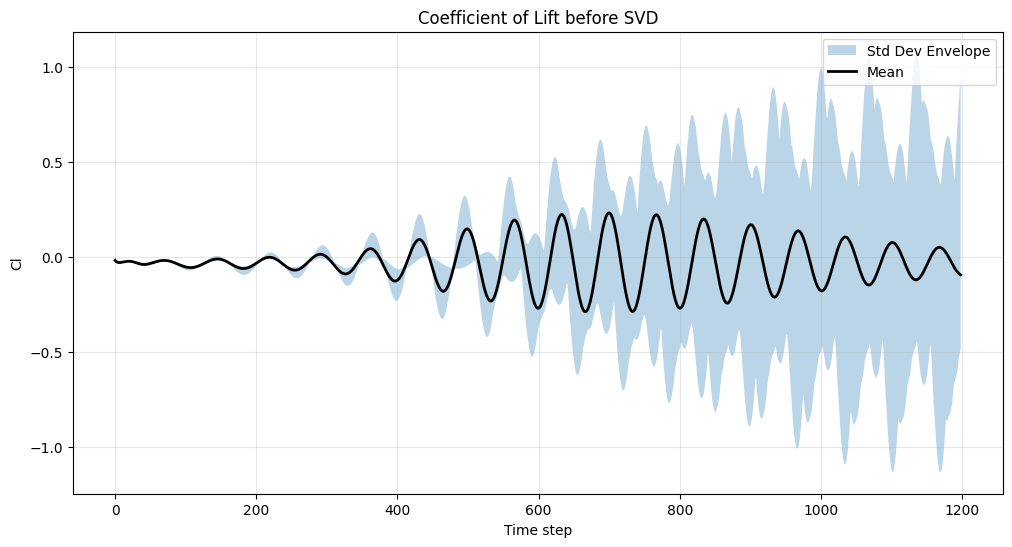

In [98]:
# Select the data for centering for PCA
time_len = 1199
num_samples = 100 

data = Cl_data  # select Cl_data or Cd_data
data_mean = data.mean(axis=1, keepdims=True)
data_centered = data - data_mean
data_std = data.std(axis=1, keepdims=True)
data_min = data.min(axis=1)
data_max = data.max(axis=1)
# Plotting the data before SVD
plt.figure(figsize=(12, 6))
plt.fill_between(range(time_len), data_min, data_max, alpha=0.3, label='Std Dev Envelope')
plt.plot(data_mean, 'k-', linewidth=2, label='Mean')
if data is Cd_data:
    plt.xlabel('Time step')
    plt.ylabel('Cd')
    plt.title('Coefficient of Drag before SVD')
else:
    plt.xlabel('Time step')
    plt.ylabel('Cl')
    plt.title('Coefficient of Lift before SVD')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

### calculating the SVD 

Text(0, 0.5, 'singular values')

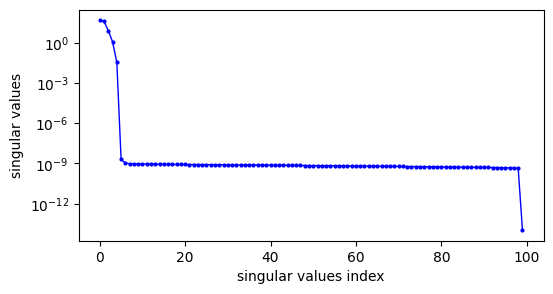

In [99]:
U,S,Vt = np.linalg.svd(data_centered, full_matrices=False)

plt.figure(figsize = (6,3))
plt.semilogy(S, 'bo-', linewidth=1, markersize= 2)
plt.xlabel('singular values index')
plt.ylabel('singular values')

## Compressed Sensing 

#### Comparing the reconstructions obtained through different compressed sensing methods:

- We compare the reconstruction of a particular sample out of 100

In [106]:
from sklearn.linear_model import Lasso, Ridge, LassoLars

sample_id = 10                              # select a sample to reconstruct
n_modes = 100                               # number of modes to use for reconstruction
#  it was found that using 5 node is enough for the OLS to reconstruct the signal with a very low error
# but for the Lasso and LARS we need to use more modes to get a good reconstruction.
# so using all 100 modes to add more modes, but it will also increase the computational cost.
measurement_rate = 0.01              # percentage of time steps to measure (sparsity level)  
num_measurements = int(measurement_rate * time_len)

# full x for the selected sample
x_full = data_centered[:, sample_id] # shape: (1199,select a sample to reconstruct)

# for random sampling
np.random.seed(42)
measurement_indices = np.random.choice(time_len, num_measurements, replace=False)

# construct the measurement matrix
Phi = np.zeros((num_measurements, time_len))
for i, idx in enumerate(measurement_indices):
    Phi[i, idx] = 1

# construct the dictionary using the first n_modes left singular vectors
A = Phi @ U[:, :n_modes]  # shape: (1199, n_modes)

# sparse observation 
y = Phi @ x_full  # shape: (num_measurements,)

- In y = $\Phi$ U s, we solve for s 

In [107]:
# function to compare compressed sensing methods
def compressed_sensing(alpha, sample_idx=sample_id, n_modes=n_modes, measurement_rate=measurement_rate):
    
    
    # Ridge (OLS)
    ridge = Ridge(alpha=1e-16, fit_intercept=False, max_iter=10000)
    ridge.fit(A, y)
    coef_ols = ridge.coef_
    x_ols = U[:, :n_modes] @ coef_ols
    error_ols = np.linalg.norm(x_full - x_ols) / np.linalg.norm(x_full)
    sparsity_ols = np.sum(np.abs(coef_ols)   > 1e-6)

    # Lasso
    lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000)
    lasso.fit(A, y)
    coef_lasso = lasso.coef_
    x_lasso = U[:, :n_modes] @ coef_lasso
    error_lasso = np.linalg.norm(x_full - x_lasso) / np.linalg.norm(x_full)
    sparsity_lasso = np.sum(np.abs(coef_lasso) > 1e-6)

    # LARS
    lars = LassoLars(alpha=alpha, fit_intercept=False, max_iter=10000)
    lars.fit(A, y)
    coef_lars = lars.coef_
    x_lars = U[:, :n_modes] @ coef_lars
    error_lars = np.linalg.norm(x_full - x_lars) / np.linalg.norm(x_full)
    sparsity_lars = np.sum(np.abs(coef_lars) > 1e-6)

    # Plotting
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # Original and points of measurement
    ax = axes[0]
    ax.plot(x_full + data_mean.flatten(), 'k-', linewidth=3, alpha=0.5, label='Original Cl')
    ax.plot(measurement_indices, y + data_mean.flatten()[measurement_indices], 'ro', label='Measurements')
    ax.set_title('Original and measurement points')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Cl')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # OLS
    ax = axes[1]
    ax.plot(x_full + data_mean.flatten(), 'k-', linewidth=3, alpha=0.5, label='Original')
    ax.plot(x_ols + data_mean.flatten(), 'b-', linewidth=1, label='OLS')
    ax.set_title(f'OLS\nError: {error_ols:.4f}, Sparsity: {sparsity_ols}/{n_modes}')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Cl')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Lasso
    ax = axes[2]
    ax.plot(x_full + data_mean.flatten(), 'k-', linewidth=3, alpha=0.5, label='Original')
    ax.plot(x_lasso + data_mean.flatten(), 'r-', linewidth=1, label='Lasso')
    ax.set_title(f'Lasso (α={alpha:.4f})\nError: {error_lasso:.4f}, Sparsity: {sparsity_lasso}/{n_modes}')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Cl')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # LARS
    ax = axes[3]
    ax.plot(x_full + data_mean.flatten(), 'k-', linewidth=3, alpha=0.5, label='Original')
    ax.plot(x_lars + data_mean.flatten(), 'g-', linewidth=1, label='LARS')
    ax.set_title(f'LARS (α={alpha:.4f})\nError: {error_lars:.4f}, Sparsity: {sparsity_lars}/{n_modes}')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Cl')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'Compressed Sensing Reconstruction (Sample {sample_idx}, n_modes={n_modes}, measurement_rate={measurement_rate*100:.1f}%)', fontsize=16)
    plt.tight_layout()
    plt.show()

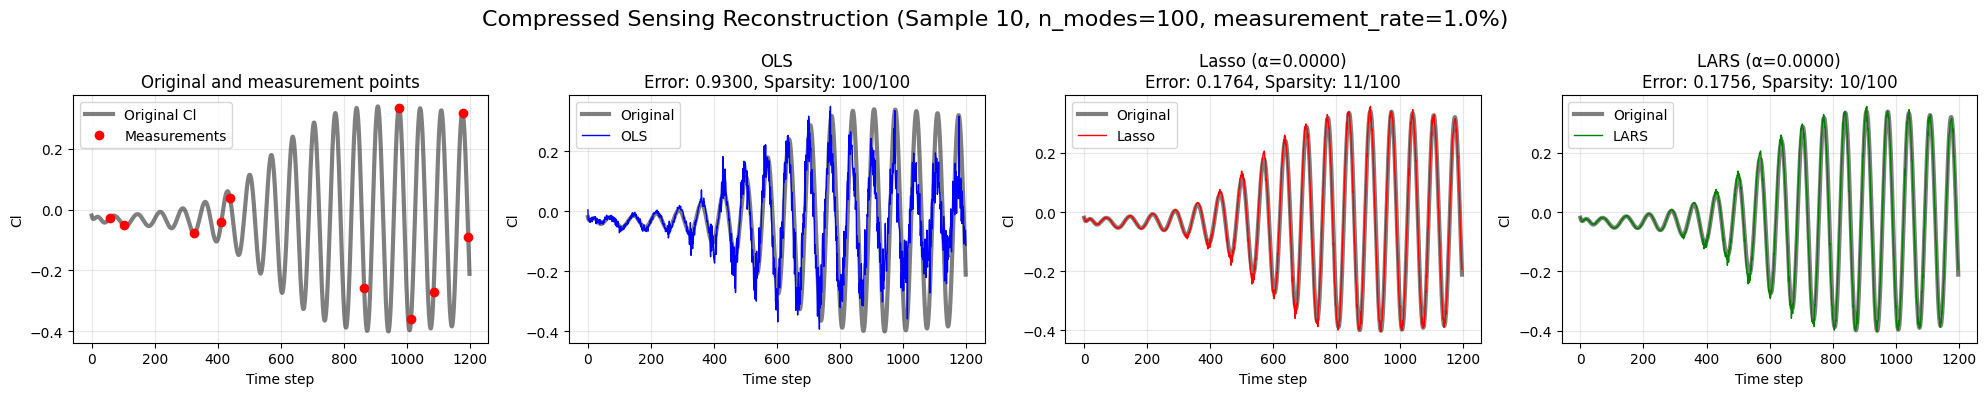

In [108]:
# trying different alpha values for compressed sensing methods
compressed_sensing(alpha=0.00001)

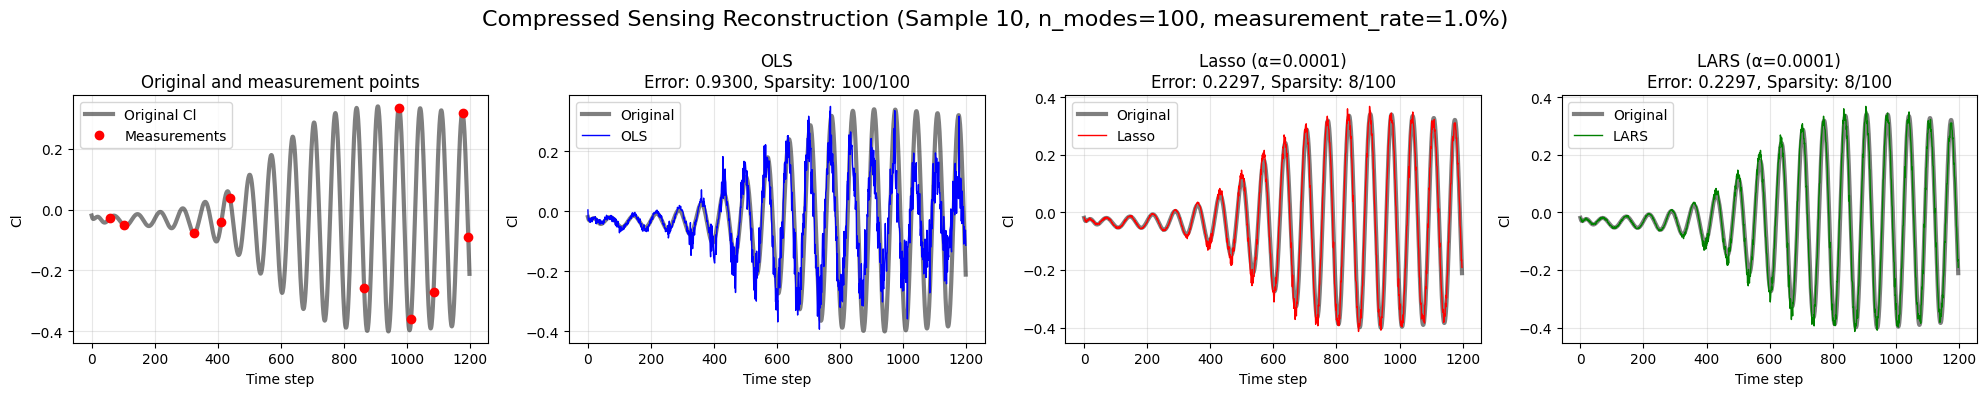

In [109]:
compressed_sensing(alpha = 0.0001)

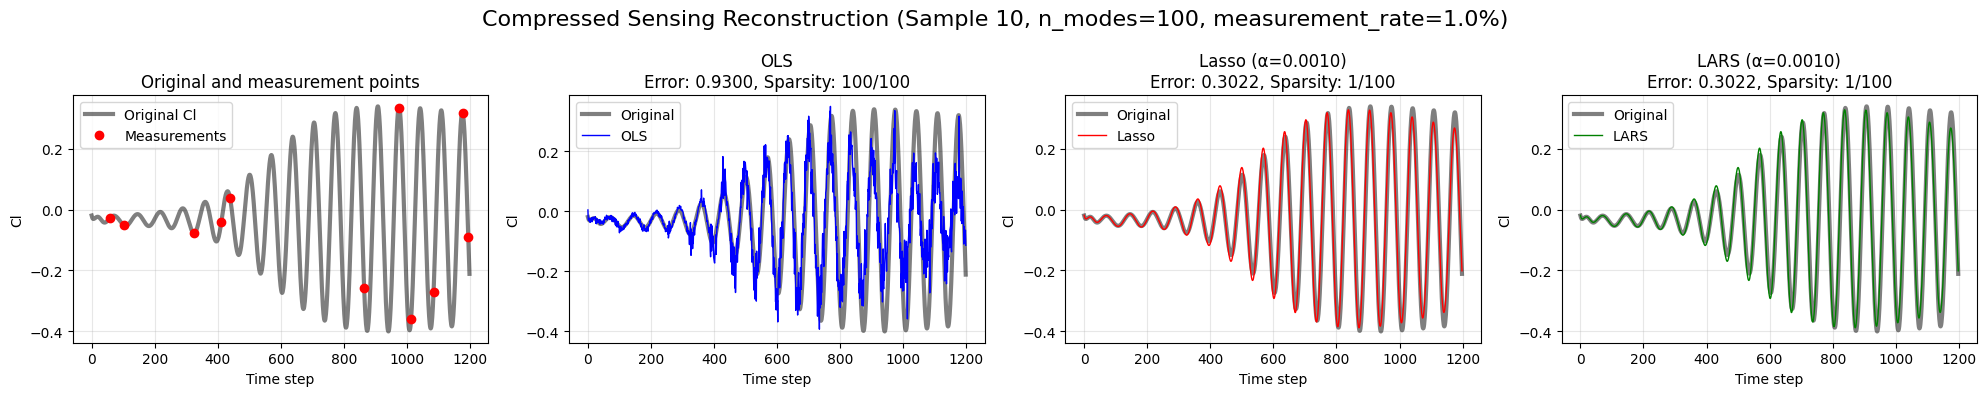

In [110]:
compressed_sensing(alpha=0.001)

Results: We see Lasso and LARS shows better reconstruction abilites than OLS when all the modes are used. 

## POD-QDEIM - Optimal Sensor Placement

- Here we compare random vs optimal sensor placement 

In [111]:
# reconstructing with sensors 
def reconstruct_with_sensors(sensor_indices, n_modes):
    # resonctructing all the samples 
    n_sensors = len(sensor_indices)
    U_r = U[:, :n_modes]  # shape: (1199, n_modes)

    # construct the measurement matrix for sensors
    Phi_sensors = np.zeros((n_sensors, time_len))
    for i, idx in enumerate(sensor_indices):
        Phi_sensors[i, idx] = 1

    # sensing matrix for sensors
    A_sensors = Phi_sensors @ U_r  # shape: (n_sensors, n_modes)

    errors = []
    for j in range(num_samples):
        x_true = data_centered[:,j]
        y_meas = Phi_sensors @ x_true
        coef = np.linalg.lstsq(A_sensors, y_meas, rcond=None)[0]
        x_recon = U_r @ coef
        errors.append(np.linalg.norm(x_true - x_recon) / np.linalg.norm(x_true))
    return np.array(errors)

# different distrubution of sensors placement
# random sensor placement
def random_sensors(n_sensors):
    np.random.seed(42)
    return np.random.choice(time_len, n_sensors, replace=False)

# QDEIM sensor placement
from scipy.linalg import qr
def qdeim_sensors(n_sensors, n_modes):
    U_r = U[:, :n_modes]
    Q, R, P = qr(U_r.T, pivoting=True)
    return P[:n_sensors]

In [112]:
# comparision function
def compare_sensor_placements(n_sensors = 11, n_modes = 5):
    random_indices = random_sensors(n_sensors)
    qdeim_indices = qdeim_sensors(n_sensors, n_modes)

    error_random = reconstruct_with_sensors(random_indices, n_modes)
    error_qdeim = reconstruct_with_sensors(qdeim_indices, n_modes)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # error distribution 
    bp = axes[0].boxplot([error_random, error_qdeim], tick_labels=['Random Sensors', 'QDEIM Sensors'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightgreen')
    axes[0].set_ylabel('Relative Reconstruction Error')
    axes[0].set_title(f'Comparison of Sensor Placements (n_sensors={n_sensors}, n_modes={n_modes})')
    axes[0].grid(True, alpha=0.3)

    # sensor locations plotted over original data 
    axes[1].plot(data_mean, 'k-', linewidth=2, label='Mean Cl')
    axes[1].plot(random_indices, data_mean.flatten()[random_indices], 'ro', label='Random Sensors')
    axes[1].plot(qdeim_indices, data_mean.flatten()[qdeim_indices], 'go', label='QDEIM Sensors')
    axes[1].set_xlabel('Time step')
    axes[1].set_ylabel('Cl')
    axes[1].set_title('Sensor Locations on Mean Cl')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

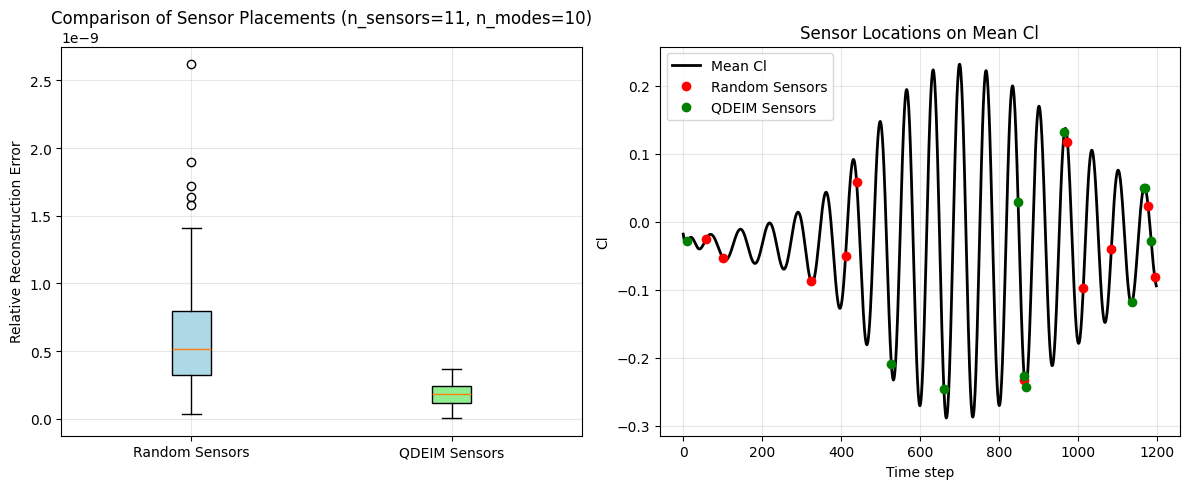

In [117]:
compare_sensor_placements(n_sensors=11, n_modes=10) # 1% of the measurement from Compressed sensing

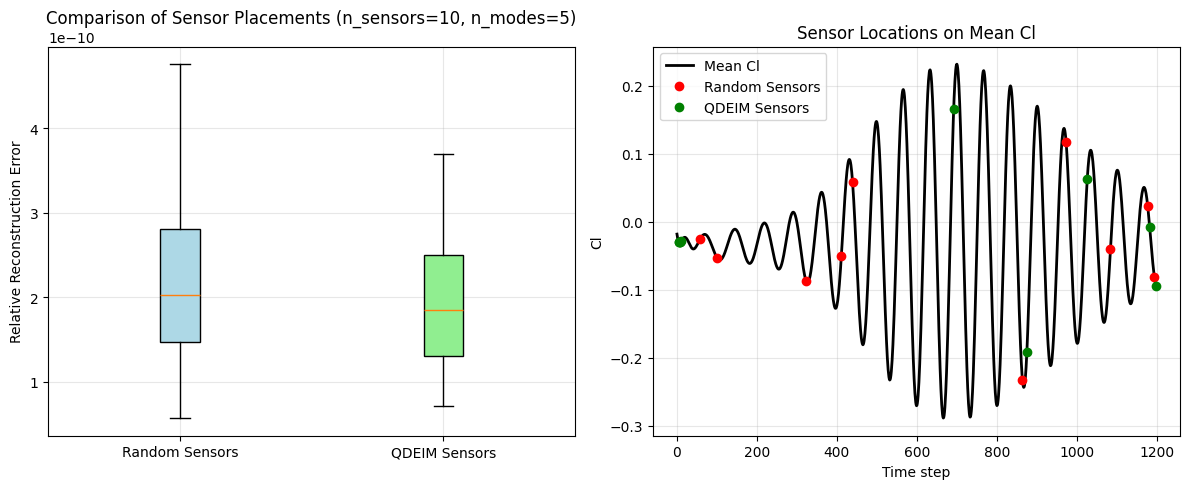

In [118]:
compare_sensor_placements(n_sensors=10, n_modes=5)

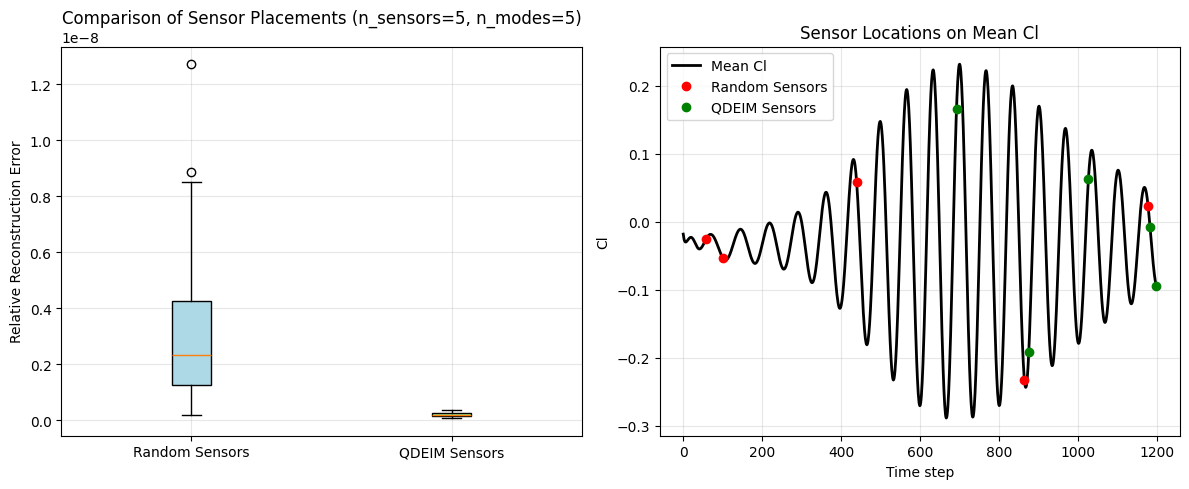

In [119]:
compare_sensor_placements(n_sensors=5, n_modes=5)

In [146]:
# example construction of the signal using the sensor placement
def example_construction(sensor_indices, n_modes, sample_idx):
    U_r = U[:, :n_modes]
    Phi_sensors = np.zeros((len(sensor_indices), time_len))
    for i, idx in enumerate(sensor_indices):
        Phi_sensors[i, idx] = 1
    A_sensors = Phi_sensors @ U_r

    x_true = data_centered[:, sample_idx]
    y_meas = Phi_sensors @ x_true
    coef = np.linalg.lstsq(A_sensors, y_meas, rcond=None)[0]
    x_recon = U_r @ coef

    plt.figure(figsize=(10, 5))
    plt.plot(x_true + data_mean.flatten(), 'k-', linewidth=1, alpha=1, label='Original Cl')
    plt.plot(x_recon + data_mean.flatten(), 'r-', linewidth=4, alpha=0.5, label='Reconstructed Cl')
    plt.xlabel('Time step')
    plt.ylabel('Cl')
    plt.title(f'Example Reconstruction using Sensors (n_modes={n_modes} for samples {sample_idx})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

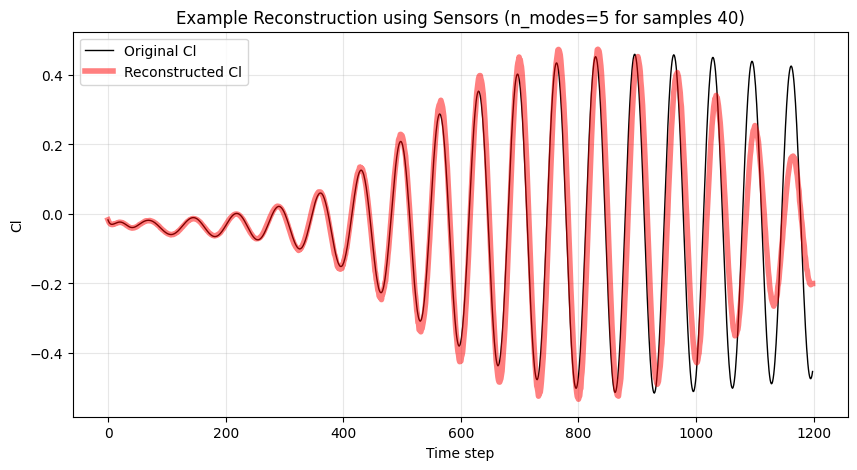

In [160]:
example_construction(random_sensors(n_sensors=4), n_modes=5, sample_idx=40) # needs more than 4 sensors

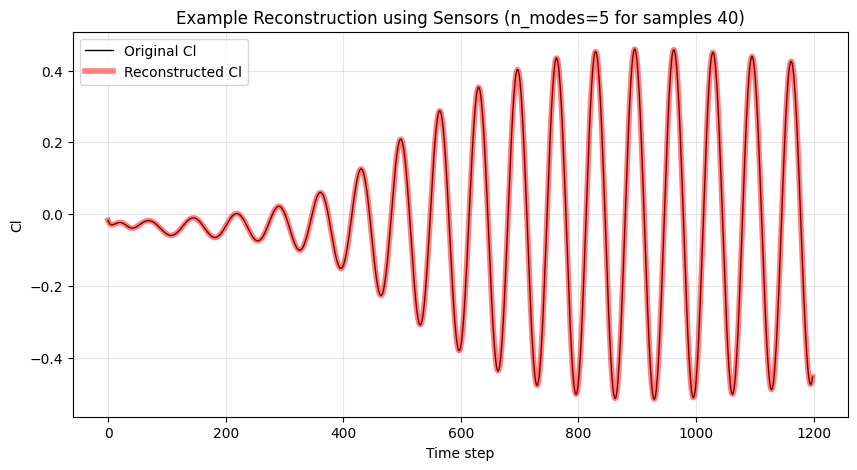

In [161]:
example_construction(random_sensors(n_sensors=5), n_modes=5, sample_idx=40)

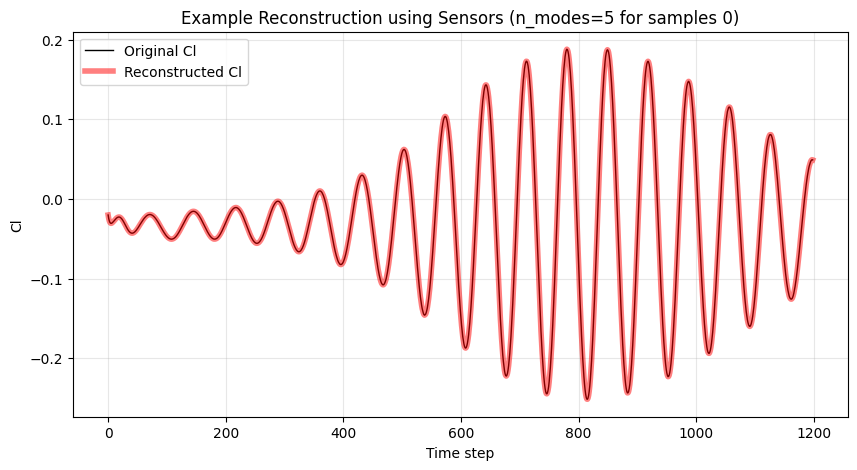

In [162]:
example_construction(random_sensors(n_sensors=5), n_modes=5, sample_idx=0)

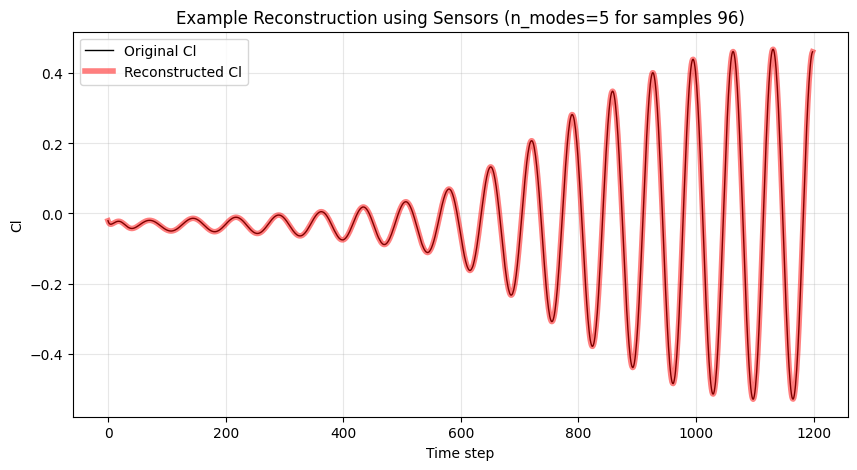

In [163]:
example_construction(random_sensors(n_sensors=5), n_modes=5, sample_idx=96)

Results: This shows that with optimal placement of the sensors the samples can be reconstructed with just 5 sensor points for the data of coefficient of lifts.